# Makine Öğrenimi Modelleriyle AAPL Getiri Tahmini

Bu notebook, AAPL hissesinin bir sonraki işlem günündeki log getirisini tahmin eden klasik makine öğrenimi modellerini karşılaştırır.

## 1. Kütüphaneler ve Ayarlar

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore",category=UserWarning)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

## 2. Veri Yükleme

In [18]:
data = pd.read_csv("data/filled_aapl.csv", parse_dates=["Date"], index_col="Date")
data.index = pd.to_datetime(data.index, utc=True)
data = data.sort_index()

print(f"Veri boyutu: {data.shape}")
print(f"Tarih araligi: {data.index.min().date()} - {data.index.max().date()}")
display(data.head())

Veri boyutu: (11686, 7)
Tarih araligi: 1980-12-12 - 2025-09-26


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 05:00:00+00:00,0.098485,0.098913,0.098485,0.098485,469033600.0,0.0,0.0
1980-12-15 05:00:00+00:00,0.093775,0.093775,0.093347,0.093347,175884800.0,0.0,0.0
1980-12-16 05:00:00+00:00,0.086924,0.086924,0.086495,0.086495,105728000.0,0.0,0.0
1980-12-17 05:00:00+00:00,0.088636,0.089064,0.088636,0.088636,86441600.0,0.0,0.0
1980-12-18 05:00:00+00:00,0.091206,0.091634,0.091206,0.091206,73449600.0,0.0,0.0


## 3. Özellik Mühendisliği

Hedef değişken `target`, bir sonraki işlem gününün log getirisidir. Özellikler yalnızca tahmin anında bilinen bugünün ve geçmiş günlerin verileriyle oluşturulur. Böylece ileriye dönük veri sızıntısı önlenir.

In [19]:
df = data.copy()

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["hl_range"] = np.log(df["High"] / df["Low"])
df["oc_return"] = np.log(df["Close"] / df["Open"])
df["co_return"] = np.log(df["Open"] / df["Close"].shift(1))
df["volume_change"] = np.log(df["Volume"].replace(0, np.nan) / df["Volume"].replace(0, np.nan).shift(1))
df["dollar_volume"] = np.log((df["Close"] * df["Volume"]).replace(0, np.nan))

for lag in range(1, 16):
    df[f"log_return_lag{lag}"] = df["log_return"].shift(lag - 1)

for window in [5, 10, 20, 60]:
    df[f"volatility_{window}"] = df["log_return"].rolling(window).std()
    df[f"momentum_{window}"] = df["log_return"].rolling(window).sum()
    df[f"mean_return_{window}"] = df["log_return"].rolling(window).mean()

delta = df["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df["RSI_14"] = 100 - (100 / (1 + gain / loss))

for window in [20, 60]:
    df[f"close_to_ma_{window}"] = np.log(df["Close"] / df["Close"].rolling(window).mean())

df["target"] = df["log_return"].shift(-1)

df = df.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [
    col for col in df.columns
    if col not in data.columns and col not in ["log_return", "target"]
]

X = df[feature_cols]
y = df["target"]

print(f"Veri boyutu: {df.shape}")
print(f"X shape: {X.shape}")
print(f"Ozellik sayisi: {len(feature_cols)}")

Veri boyutu: (10840, 44)
X shape: (10840, 35)
Ozellik sayisi: 35


## 4. Zaman Bazlı Eğitim-Test Ayrımı

Finansal zaman serilerinde rastgele bölme kullanmak gerçekçi değildir. Bu nedenle verinin ilk %80'i eğitim, son %20'si test için ayrılır.

In [20]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx - 1], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx - 1], y.iloc[split_idx:]

print(f"Egitim seti: {X_train.shape[0]} gozlem ({X_train.index.min().date()} - {X_train.index.max().date()})")
print(f"Test seti: {X_test.shape[0]} gozlem ({X_test.index.min().date()} - {X_test.index.max().date()})")

Egitim seti: 8671 gozlem (1981-03-06 - 2016-10-05)
Test seti: 2168 gozlem (2016-10-07 - 2025-09-25)


## 5. Model Tanımları

Bu bölümde Linear Regression, Decision Tree, Random Forest, Gradient Boosting, k-NN, SVR, XGBoost ve LightGBM modelleri karşılaştırılır. Parametreler, finansal getirilerde sık görülen aşırı öğrenme riskini azaltacak şekilde seçilmiştir.

In [21]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=4,
        min_samples_leaf=20,
        max_features=0.5,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.02,
        max_depth=1,
        subsample=0.7,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=100,
            weights="uniform",
            metric="manhattan"
        ))
    ]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=0.1, epsilon=0.01, kernel="rbf"))
    ]),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=150,
        learning_rate=0.02,
        max_depth=1,
        subsample=0.7,
        colsample_bytree=0.8,
        reg_lambda=20,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=150,
        learning_rate=0.02,
        num_leaves=3,
        subsample=0.7,
        colsample_bytree=0.8,
        reg_lambda=20,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1
    )
}

## 6. Eğitim ve Test Sonuçları

In [22]:
results = {}

def record_model_result(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "predictions": y_pred,
        "model": model,
    }
    print(f"{name} - MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")




def readable_feature_name(feature_name):
    if feature_name.startswith("log_return_lag"):
        lag = feature_name.removeprefix("log_return_lag")
        return f"Getiri gecikmesi ({lag})"
    if feature_name.startswith("volatility_"):
        window = feature_name.removeprefix("volatility_")
        return f"Volatilite ({window} gun)"
    if feature_name.startswith("momentum_"):
        window = feature_name.removeprefix("momentum_")
        return f"Momentum ({window} gun)"
    if feature_name.startswith("mean_return_"):
        window = feature_name.removeprefix("mean_return_")
        return f"Ortalama getiri ({window} gun)"
    if feature_name.startswith("close_to_ma_"):
        window = feature_name.removeprefix("close_to_ma_")
        return f"Hareketli ortalamaya uzaklik ({window} gun)"
    labels = {
        "hl_range": "Gun ici fiyat araligi",
        "oc_return": "Acilis-kapanis getirisi",
        "co_return": "Onceki kapanis-acilis getirisi",
        "volume_change": "Hacim degisimi",
        "dollar_volume": "Dolar hacmi",
        "RSI_14": "RSI (14 gun)",
    }
    return labels.get(feature_name, feature_name)


def calculate_feature_importance(model, model_name):
    if hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
        importance_method = "Model ozelligi"

    elif isinstance(model, Pipeline) and hasattr(model.named_steps["model"], "coef_"):
        importance_values = np.abs(model.named_steps["model"].coef_)
        importance_method = "Mutlak katsayi"

    else:
        if model_name == "SVR":
            permutation = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=3,
                max_samples=min(300, len(X_test)),
                random_state=RANDOM_STATE,
                scoring="neg_root_mean_squared_error",
                n_jobs=1
            )
        else:
            permutation = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=10,
                random_state=RANDOM_STATE,
                scoring="neg_root_mean_squared_error",
                n_jobs=1
            )

        importance_values = permutation.importances_mean
        importance_method = "Permutasyon"

    importance_df = pd.DataFrame({
        "Feature": [readable_feature_name(feature) for feature in feature_cols],
        "Importance": np.asarray(importance_values, dtype=float)
    })

    importance_df = importance_df.replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).head(3)

    if importance_df.empty:
        print(f"{model_name}: ozellik onemliligi hesaplanamadi.")
        return

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    ax.barh(
        importance_df["Feature"],
        importance_df["Importance"],
        color="#4c78a8"
    )

    ax.set_xlabel("Onem skoru")
    ax.set_title(
        f"{model_name} - En Onemli 3 Ozellik ({importance_method})",
        pad=12
    )

    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)

    ax.ticklabel_format(
        style="plain",
        axis="x",
        useOffset=False
    )

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, pos: f"{x:.8f}".rstrip("0").rstrip(".")
        )
    )

    plt.tight_layout()
    plt.show()

### 1. Linear Regression

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [23]:
record_model_result('Linear Regression', models['Linear Regression'])


Linear Regression - MSE: 0.000335, RMSE: 0.018299, MAE: 0.012413


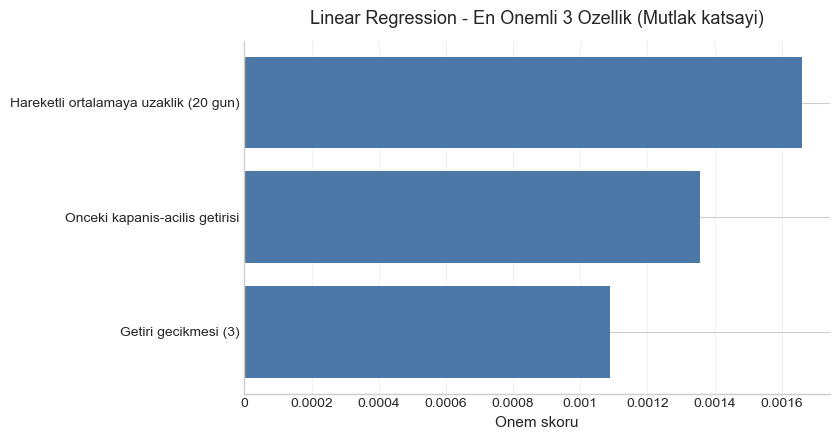

In [24]:
calculate_feature_importance(results['Linear Regression']['model'], 'Linear Regression')


### 2. Decision Tree

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [25]:
record_model_result('Decision Tree', models['Decision Tree'])


Decision Tree - MSE: 0.000337, RMSE: 0.018368, MAE: 0.012361


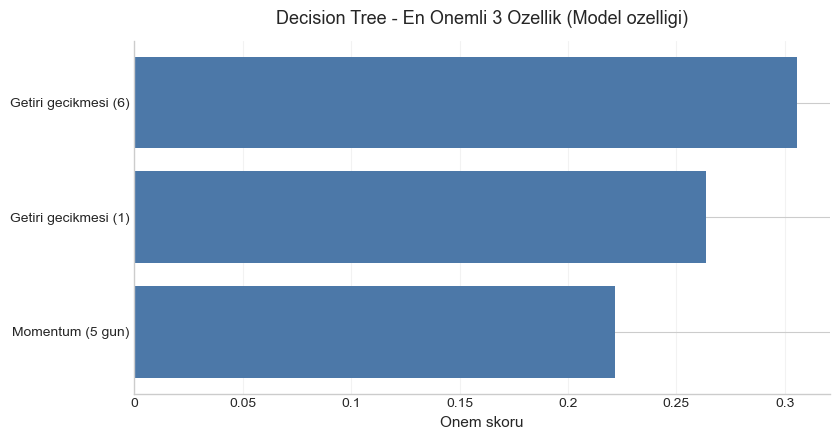

In [26]:
calculate_feature_importance(results['Decision Tree']['model'], 'Decision Tree')


### 3. Random Forest

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [27]:
record_model_result('Random Forest', models['Random Forest'])


Random Forest - MSE: 0.000335, RMSE: 0.018300, MAE: 0.012339


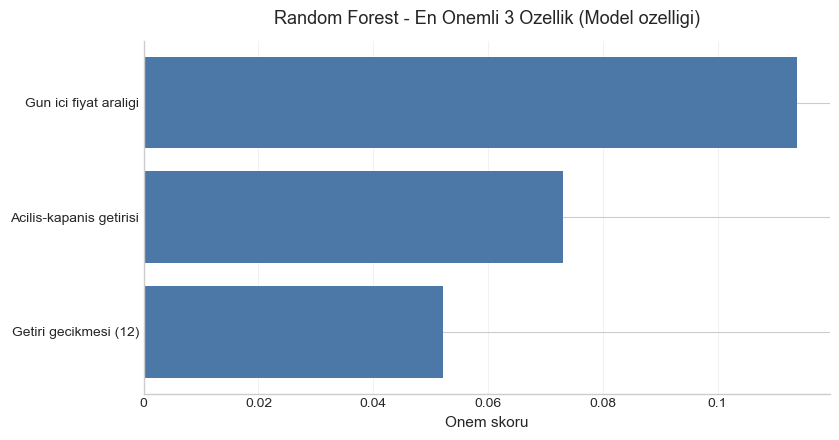

In [28]:
calculate_feature_importance(results['Random Forest']['model'], 'Random Forest')


### 4. Gradient Boosting

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [29]:
record_model_result('Gradient Boosting', models['Gradient Boosting'])


Gradient Boosting - MSE: 0.000334, RMSE: 0.018283, MAE: 0.012332


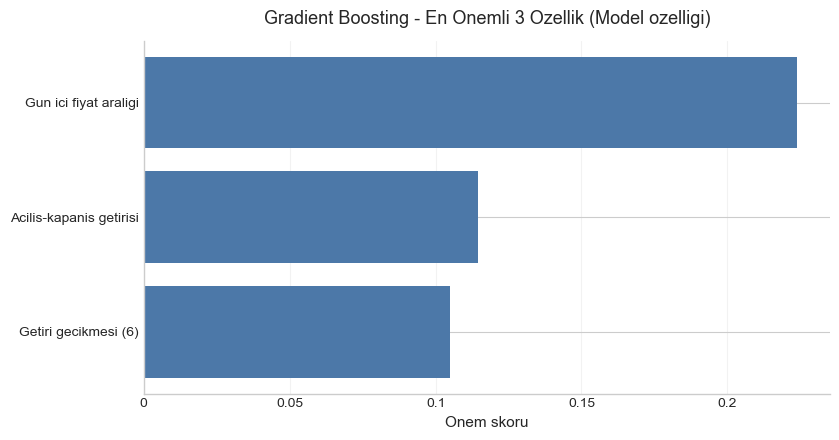

In [30]:
calculate_feature_importance(results['Gradient Boosting']['model'], 'Gradient Boosting')


### 5. k-NN

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [31]:
record_model_result('k-NN', models['k-NN'])


k-NN - MSE: 0.000329, RMSE: 0.018144, MAE: 0.012388


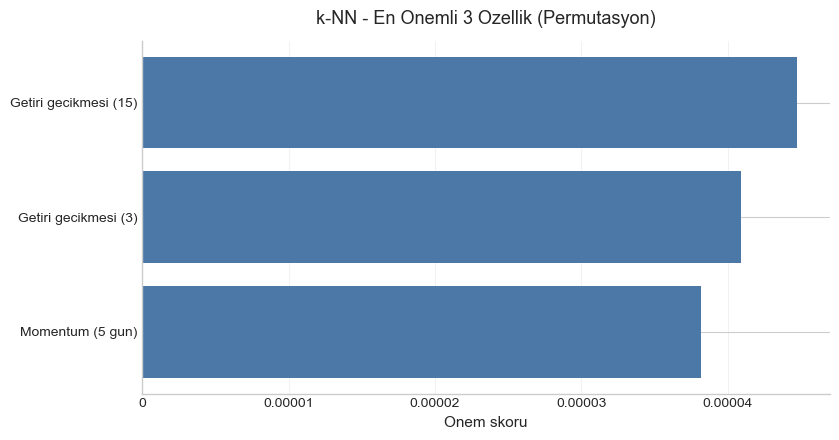

In [32]:
calculate_feature_importance(results['k-NN']['model'], 'k-NN')


### 6. SVR

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [33]:
record_model_result('SVR', models['SVR'])


SVR - MSE: 0.000349, RMSE: 0.018672, MAE: 0.012960


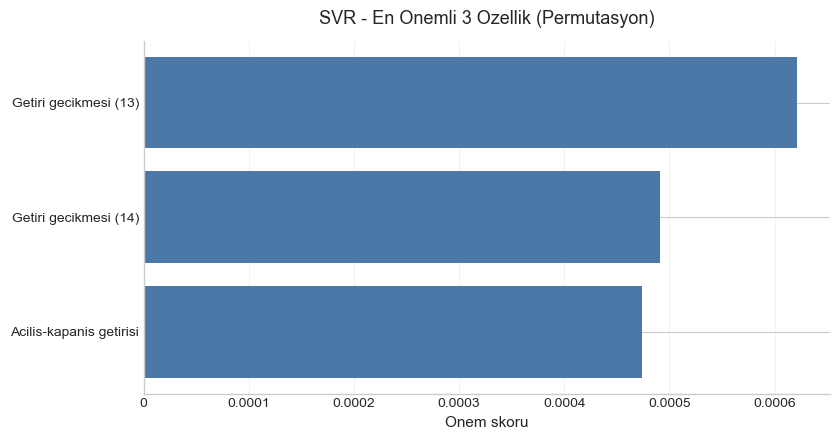

In [34]:
calculate_feature_importance(results['SVR']['model'], 'SVR')


### 7. XGBoost

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [35]:
record_model_result('XGBoost', models['XGBoost'])


XGBoost - MSE: 0.000334, RMSE: 0.018263, MAE: 0.012332


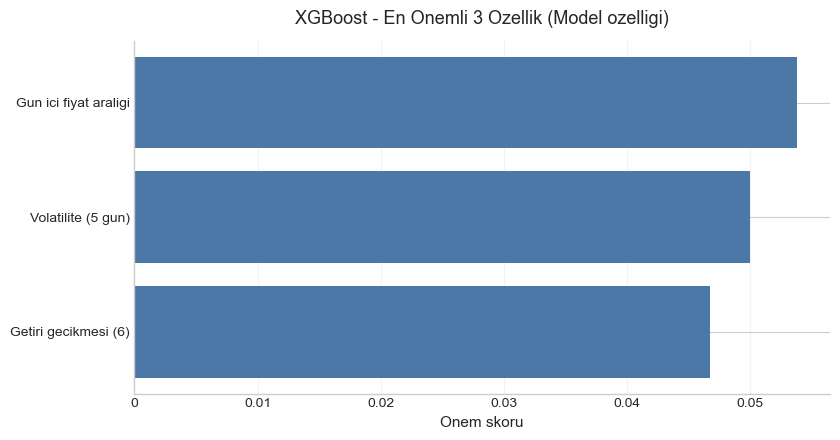

In [36]:
calculate_feature_importance(results['XGBoost']['model'], 'XGBoost')


### 8. LightGBM

Model eğitilir ve ardından özellik önemleri hesaplanır.


In [37]:
record_model_result('LightGBM', models['LightGBM'])


LightGBM - MSE: 0.000335, RMSE: 0.018315, MAE: 0.012359


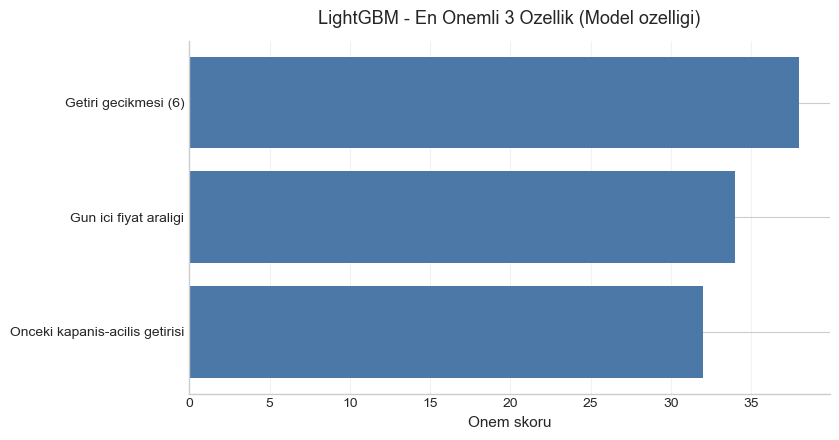

In [38]:
calculate_feature_importance(results['LightGBM']['model'], 'LightGBM')


## 7. Model Karşılaştırması

RMSE değerleri birbirine çok yakın olduğu için iki grafik kullanılır. Solda daraltılmış RMSE ekseni, sağda ise en iyi modele göre RMSE farkı baz puan cinsinden gösterilir.

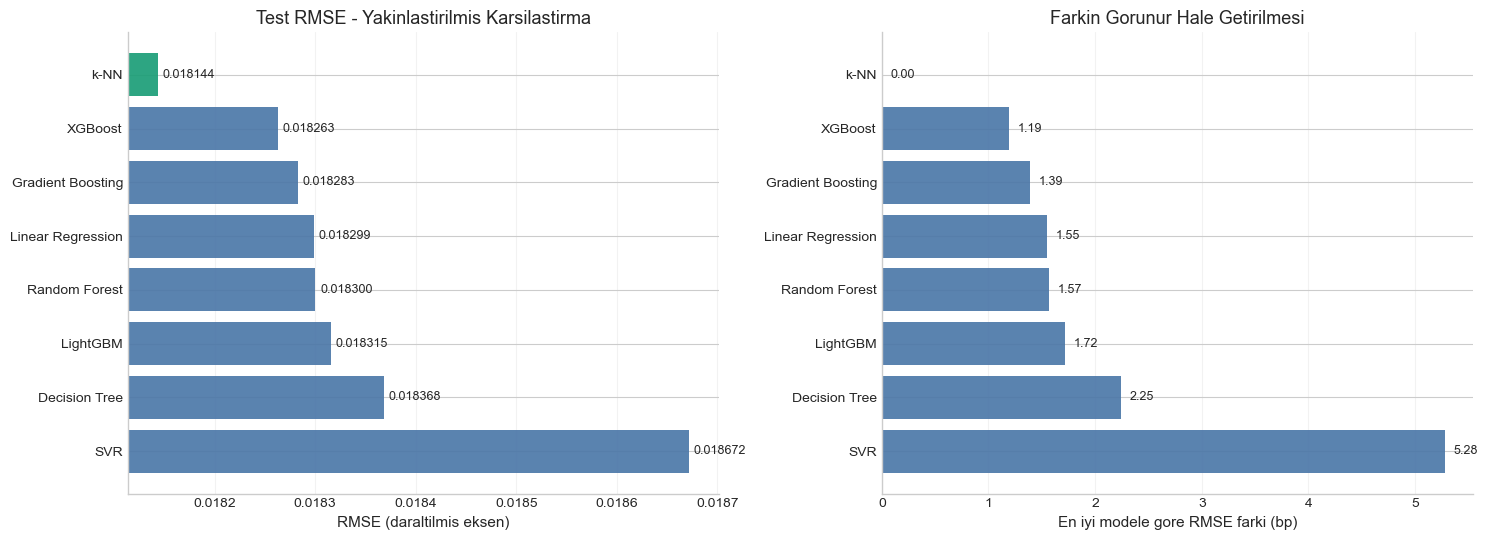

,Sira,Model,MSE,RMSE,MAE,En Iyiye RMSE Farki (bp)
4,1,k-NN,0.00032919,0.01814371,0.01238792,0.00
6,2,XGBoost,0.00033353,0.01826269,0.01233206,1.19
3,3,Gradient Boosting,0.00033425,0.01828256,0.01233161,1.39
0,4,Linear Regression,0.00033484,0.01829854,0.01241342,1.55
2,5,Random Forest,0.00033490,0.01830034,0.01233930,1.57
7,6,LightGBM,0.00033546,0.01831547,0.01235887,1.72
1,7,Decision Tree,0.00033739,0.01836829,0.01236113,2.25
5,8,SVR,0.00034863,0.01867163,0.01296014,5.28


In [39]:
results_df = pd.DataFrame([
    {
        "Model": name,
        "MSE": result["MSE"],
        "RMSE": result["RMSE"],
        "MAE": result["MAE"]
    }
    for name, result in results.items()
])

best_rmse = results_df["RMSE"].min()

results_df["En Iyiye RMSE Farki (bp)"] = (
    (results_df["RMSE"] - best_rmse) * 10000
)

plot_df = results_df.sort_values("RMSE", ascending=True).copy()
colors = ["#1b9e77" if model == plot_df.iloc[0]["Model"] else "#4c78a8" for model in plot_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x_min = plot_df["RMSE"].min() - 0.00003
x_max = plot_df["RMSE"].max() + 0.00003

axes[0].barh(
    plot_df["Model"],
    plot_df["RMSE"],
    color=colors,
    alpha=0.92
)

axes[0].set_xlim(x_min, x_max)
axes[0].invert_yaxis()
axes[0].set_xlabel("RMSE (daraltilmis eksen)")
axes[0].set_title("Test RMSE - Yakinlastirilmis Karsilastirma")
axes[0].grid(axis="x", alpha=0.25)

for y_pos, value in enumerate(plot_df["RMSE"]):
    axes[0].text(
        value + 0.000005,
        y_pos,
        f"{value:.6f}",
        va="center",
        fontsize=9
    )

axes[1].barh(
    plot_df["Model"],
    plot_df["En Iyiye RMSE Farki (bp)"],
    color=colors,
    alpha=0.92
)

axes[1].invert_yaxis()
axes[1].set_xlabel("En iyi modele gore RMSE farki (bp)")
axes[1].set_title("Farkin Gorunur Hale Getirilmesi")
axes[1].grid(axis="x", alpha=0.25)

for y_pos, value in enumerate(plot_df["En Iyiye RMSE Farki (bp)"]):
    axes[1].text(
        value + 0.08,
        y_pos,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

table_df = results_df.sort_values(
    "RMSE",
    ascending=True
).copy()

table_df.insert(
    0,
    "Sira",
    range(1, len(table_df) + 1)
)

table_df = table_df[
    [
        "Sira",
        "Model",
        "MSE",
        "RMSE",
        "MAE",
        "En Iyiye RMSE Farki (bp)"
    ]
]

table_df["MSE"] = table_df["MSE"].map(lambda x: f"{x:.8f}")
table_df["RMSE"] = table_df["RMSE"].map(lambda x: f"{x:.8f}")
table_df["MAE"] = table_df["MAE"].map(lambda x: f"{x:.8f}")

table_df["En Iyiye RMSE Farki (bp)"] = table_df[
    "En Iyiye RMSE Farki (bp)"
].map(lambda x: f"{x:.2f}")

display(table_df)

## 8. En İyi Modelin Tahminleri

Günlük getiriler çok gürültülü olduğu için tek tek tahmin çizgileri zor okunur. Bu nedenle en iyi modelin tahminleri dağılım ve kümülatif log getiri üzerinden incelenir.

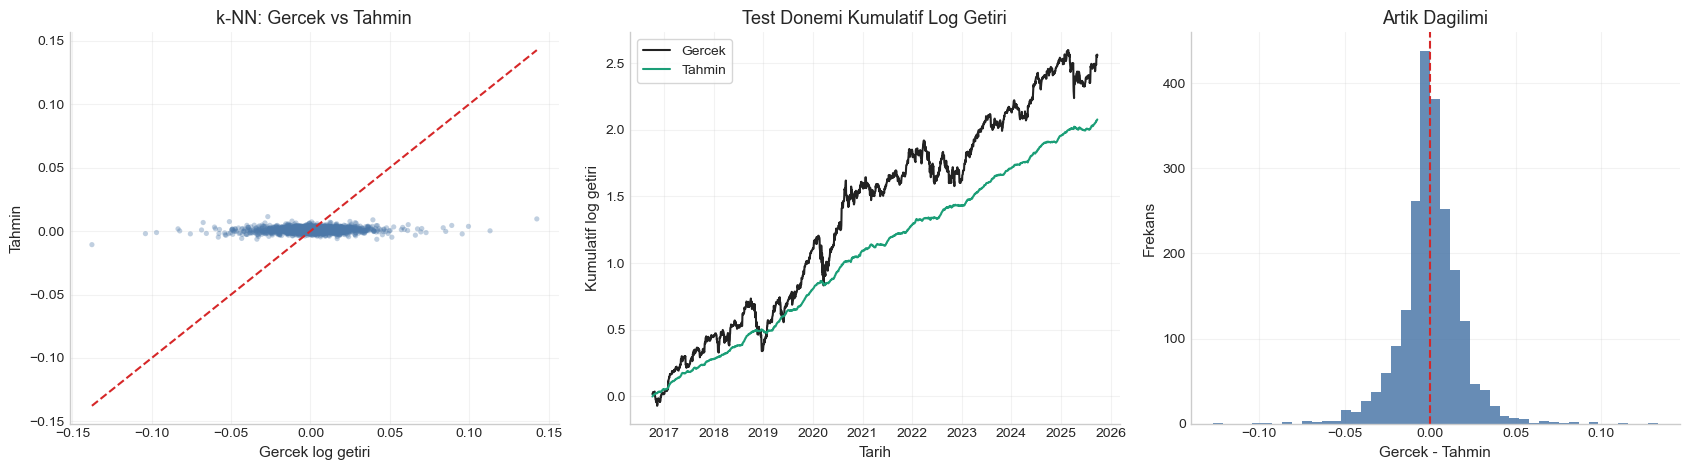

In [40]:
best_model_name = results_df.loc[results_df["RMSE"].idxmin(),"Model"]
best_pred = results[best_model_name]["predictions"]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].scatter(y_test.values, best_pred, alpha=0.35, s=14, color="#4c78a8", edgecolors="none")
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="#d62728", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Gercek log getiri")
axes[0].set_ylabel("Tahmin")
axes[0].set_title(f"{best_model_name}: Gercek vs Tahmin")
axes[0].grid(alpha=0.25)

cum_actual = pd.Series(y_test.values, index=y_test.index).cumsum()
cum_pred = pd.Series(best_pred, index=y_test.index).cumsum()
axes[1].plot(cum_actual.index, cum_actual, label="Gercek", color="#222222", linewidth=1.5)
axes[1].plot(cum_pred.index, cum_pred, label="Tahmin", color="#1b9e77", linewidth=1.5)
axes[1].set_title("Test Donemi Kumulatif Log Getiri")
axes[1].set_xlabel("Tarih")
axes[1].set_ylabel("Kumulatif log getiri")
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.25)

axes[2].hist(residuals, bins=45, color="#4c78a8", alpha=0.85)
axes[2].axvline(0, color="#d62728", linestyle="--", linewidth=1.5)
axes[2].set_title("Artik Dagilimi")
axes[2].set_xlabel("Gercek - Tahmin")
axes[2].set_ylabel("Frekans")
axes[2].grid(alpha=0.25)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Kısa Değerlendirme

Bu notebookta mevcut makine öğrenimi modelleri, düzenli özellikler ve kontrollü hiperparametrelerle karşılaştırıldı. Değerler birbirine yakın olduğu için sonuçlarda daraltılmış RMSE ekseni ve en iyi modele göre baz puan farkı birlikte gösterildi.